# Synthetic 220° stereographic calibration

This notebook builds a synthetic 220° camera, places planar calibration targets
across the full image (including observations behind the camera plane), and fits
both stereographic camera models. All distortion grids are drawn directly in the
stereographic plane, which remains finite across 180°.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import lensboy as lb
from lensboy.analysis.plots import plot_distortion_grid

Horizontal and vertical FOV: 220.0°


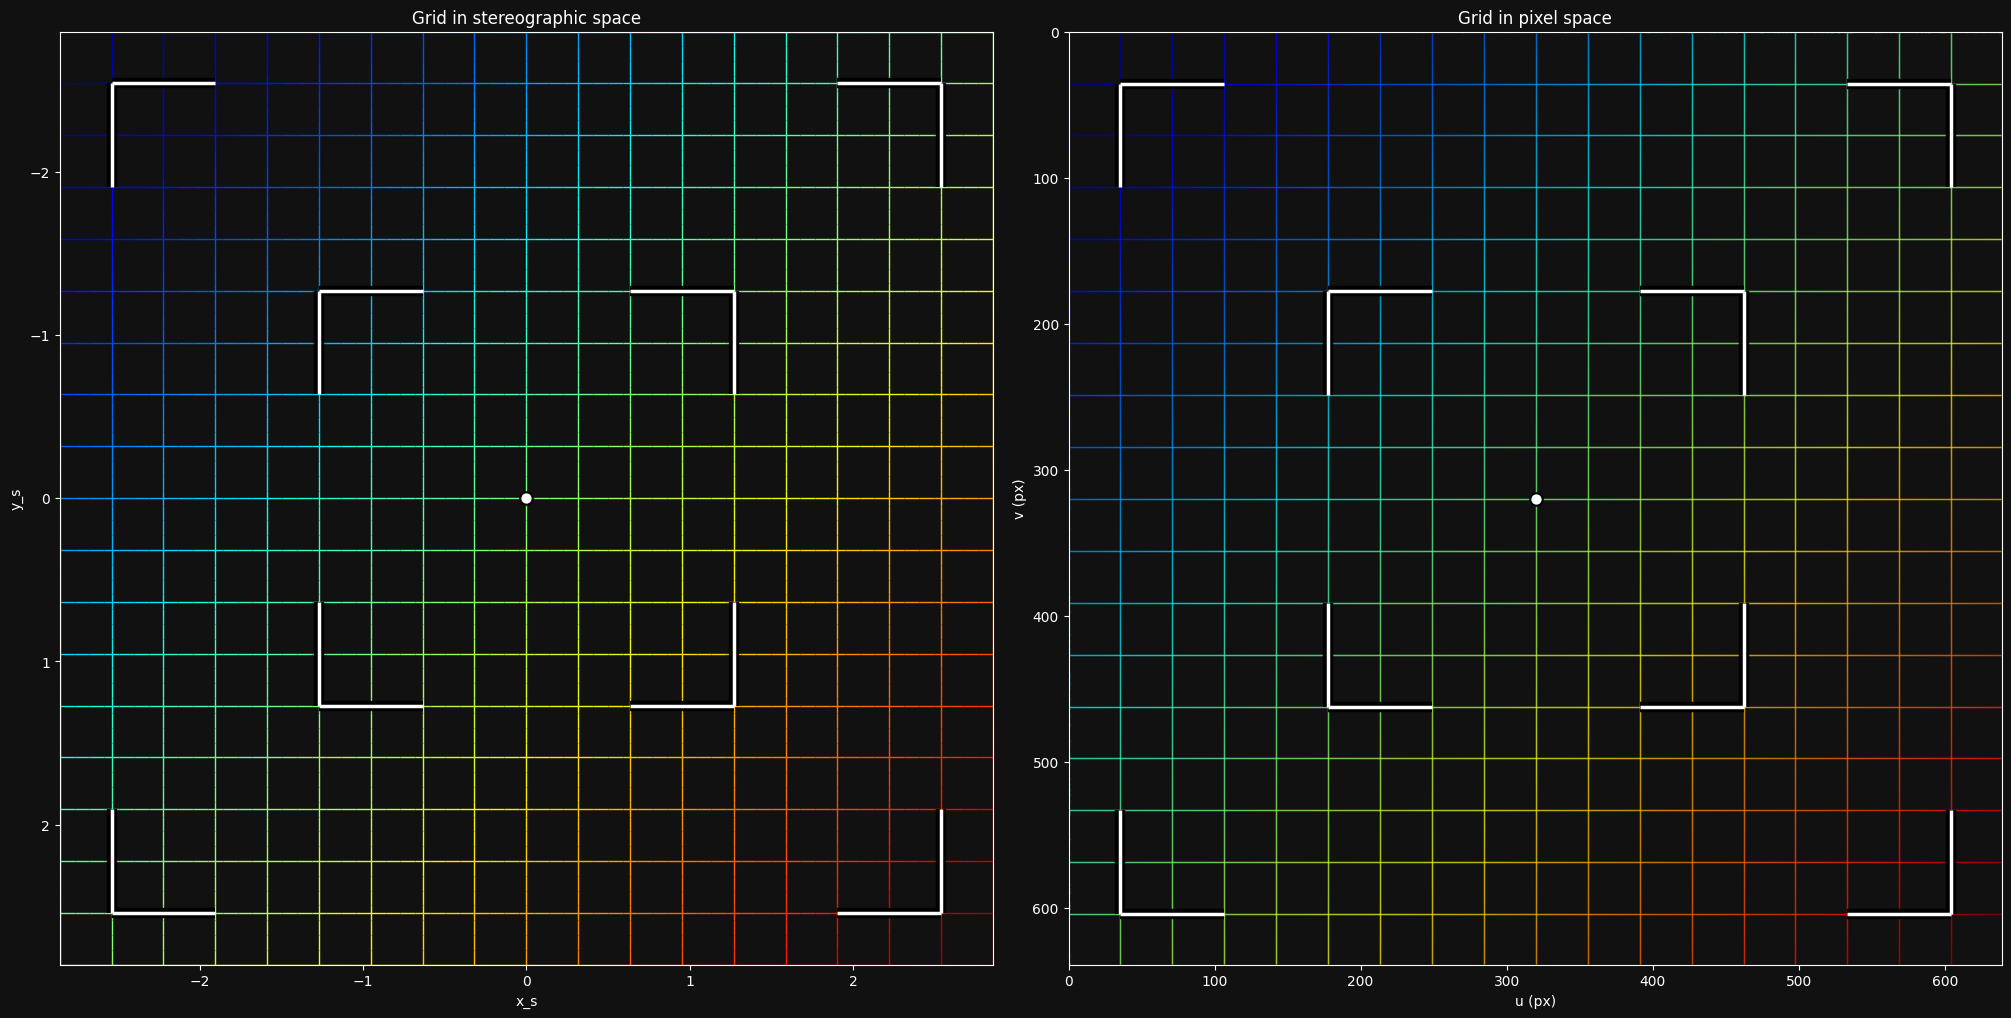

In [2]:
IMAGE_SIZE = 640
FOCAL_LENGTH = 112.0
FOV_DEG = 4.0 * np.degrees(
    np.arctan((IMAGE_SIZE / 2.0 / FOCAL_LENGTH) / 2.0)
)
print(f"Horizontal and vertical FOV: {FOV_DEG:.1f}°")

ground_truth = lb.StereographicOpenCV(
    image_width=IMAGE_SIZE,
    image_height=IMAGE_SIZE,
    fx=FOCAL_LENGTH,
    fy=FOCAL_LENGTH,
    cx=IMAGE_SIZE / 2.0,
    cy=IMAGE_SIZE / 2.0,
    distortion_coeffs=np.zeros(14),
)
plot_distortion_grid(ground_truth, grid_cells=18)

In [3]:
def make_planar_grid(
    cols: int = 10,
    rows: int = 8,
    spacing: float = 20.0,
) -> np.ndarray:
    """Create a planar calibration grid centered at the origin.

    Args:
        cols: Number of columns.
        rows: Number of rows.
        spacing: Distance between adjacent points.

    Returns:
        Target points, shape (cols * rows, 3).
    """
    xs = np.arange(cols) * spacing - (cols - 1) * spacing / 2.0
    ys = np.arange(rows) * spacing - (rows - 1) * spacing / 2.0
    grid_x, grid_y = np.meshgrid(xs, ys)
    return np.column_stack(
        [grid_x.ravel(), grid_y.ravel(), np.zeros(grid_x.size)]
    )


def generate_frames(
    rng: np.random.Generator,
    model: lb.StereographicOpenCV,
    target_points: np.ndarray,
    num_frames: int = 100,
) -> list[lb.Frame]:
    """Generate target views spanning more than 180 degrees.

    Args:
        rng: Random generator used for target placement and noise.
        model: Ground-truth camera model.
        target_points: Planar target coordinates, shape (N, 3).
        num_frames: Number of target views to generate.

    Returns:
        Synthetic calibration frames.
    """
    margin = 140.0
    center_pixels = rng.uniform(
        [margin, margin],
        [model.image_width - margin, model.image_height - margin],
        size=(num_frames, 2),
    )
    center_rays = model.normalize_points(center_pixels)
    target_radius = float(np.linalg.norm(target_points, axis=1).max())
    distance = target_radius * 0.7
    all_indices = np.arange(len(target_points))
    frames: list[lb.Frame] = []

    for center_ray in center_rays:
        reference = np.array([0.0, 1.0, 0.0])
        if abs(float(np.dot(reference, center_ray))) > 0.9:
            reference = np.array([1.0, 0.0, 0.0])
        target_x_in_camera = np.cross(reference, center_ray)
        target_x_in_camera /= np.linalg.norm(target_x_in_camera)
        target_y_in_camera = np.cross(center_ray, target_x_in_camera)

        roll = rng.uniform(-np.pi, np.pi)
        cos_roll = np.cos(roll)
        sin_roll = np.sin(roll)
        rolled_x = cos_roll * target_x_in_camera + sin_roll * target_y_in_camera
        rolled_y = -sin_roll * target_x_in_camera + cos_roll * target_y_in_camera
        camera_from_target = lb.Pose.from_rotmat_trans(
            rotmat=np.column_stack([rolled_x, rolled_y, center_ray]),
            trans=center_ray * distance,
        )
        points_in_camera = camera_from_target.apply(target_points)
        projected = model.project_points(points_in_camera)
        in_bounds = (
            (projected[:, 0] >= 0.0)
            & (projected[:, 0] < model.image_width)
            & (projected[:, 1] >= 0.0)
            & (projected[:, 1] < model.image_height)
        )
        if in_bounds.sum() < 10:
            continue
        detections = projected[in_bounds] + rng.normal(
            scale=0.05,
            size=(in_bounds.sum(), 2),
        )
        frames.append(
            lb.Frame(
                target_point_indices=all_indices[in_bounds],
                detected_points_in_image=detections,
            )
        )

    return frames

Generated 100 frames


Text(0.5, 1.0, 'Synthetic detections across the 220° image')

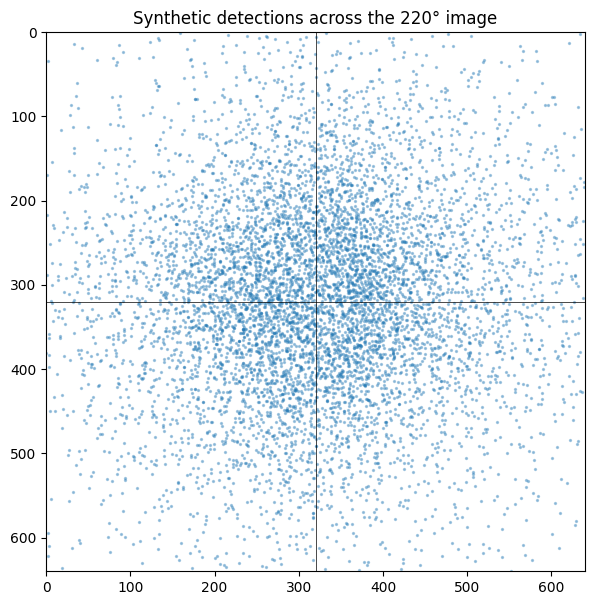

In [4]:
target_points = make_planar_grid()
frames = generate_frames(
    np.random.default_rng(20260820),
    ground_truth,
    target_points,
)
print(f"Generated {len(frames)} frames")

detections = np.concatenate(
    [frame.detected_points_in_image for frame in frames],
    axis=0,
)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(detections[:, 0], detections[:, 1], s=2, alpha=0.35)
ax.axvline(IMAGE_SIZE / 2.0, color="black", linewidth=0.5)
ax.axhline(IMAGE_SIZE / 2.0, color="black", linewidth=0.5)
ax.set(xlim=(0, IMAGE_SIZE), ylim=(IMAGE_SIZE, 0), aspect="equal")
ax.set_title("Synthetic detections across the 220° image")

In [5]:
stereographic_opencv_result = lb.calibrate_camera(
    target_points,
    frames,
    camera_model_config=lb.StereographicOpenCVConfig(
        image_height=IMAGE_SIZE,
        image_width=IMAGE_SIZE,
        initial_focal_length=120.0,
        included_distortion_coefficients=lb.StereographicOpenCVConfig.NONE,
    ),
    estimate_target_warp=False,
)
stereographic_opencv_result

Computing initial poses with stereographic PnP...


PnP solved 100/100 frames


Stereographic OpenCV pass 1: 0.0s (mean reproj=0.061px, worst=0.198px)


CalibrationResult(
  model=StereographicOpenCV(640x640, f=[112.0, 112.0], c=[320.0, 320.0], 0 distortion coeffs),
  frames=100, detections=7494, outliers=0,
  residual_sigma=0.0489px
)

In [6]:
stereographic_spline_result = lb.calibrate_camera(
    target_points,
    frames,
    camera_model_config=lb.StereographicSplinedConfig(
        image_height=IMAGE_SIZE,
        image_width=IMAGE_SIZE,
        num_knots_x=12,
        num_knots_y=12,
        initial_focal_length=120.0,
        fov_deg_xy=(225.0, 225.0),
    ),
    estimate_target_warp=False,
)
stereographic_spline_result

Computing initial poses with stereographic PnP...


PnP solved 100/100 frames


Stereographic OpenCV pass 1: 0.2s (mean reproj=0.061px, worst=0.197px)


Stereographic spline FOV (user-specified): 225.0° x 225.0°


Stereographic spline pass 1: 2.6s (mean reproj=0.061px, worst=0.194px)


CalibrationResult(
  model=StereographicSplined(640x640, f=[112.1, 112.0], c=[320.0, 315.1], knots=12x12, fov=[225.0°, 225.0°]),
  frames=100, detections=7494, outliers=0,
  residual_sigma=0.0485px
)

## Stereographic OpenCV diagnostics

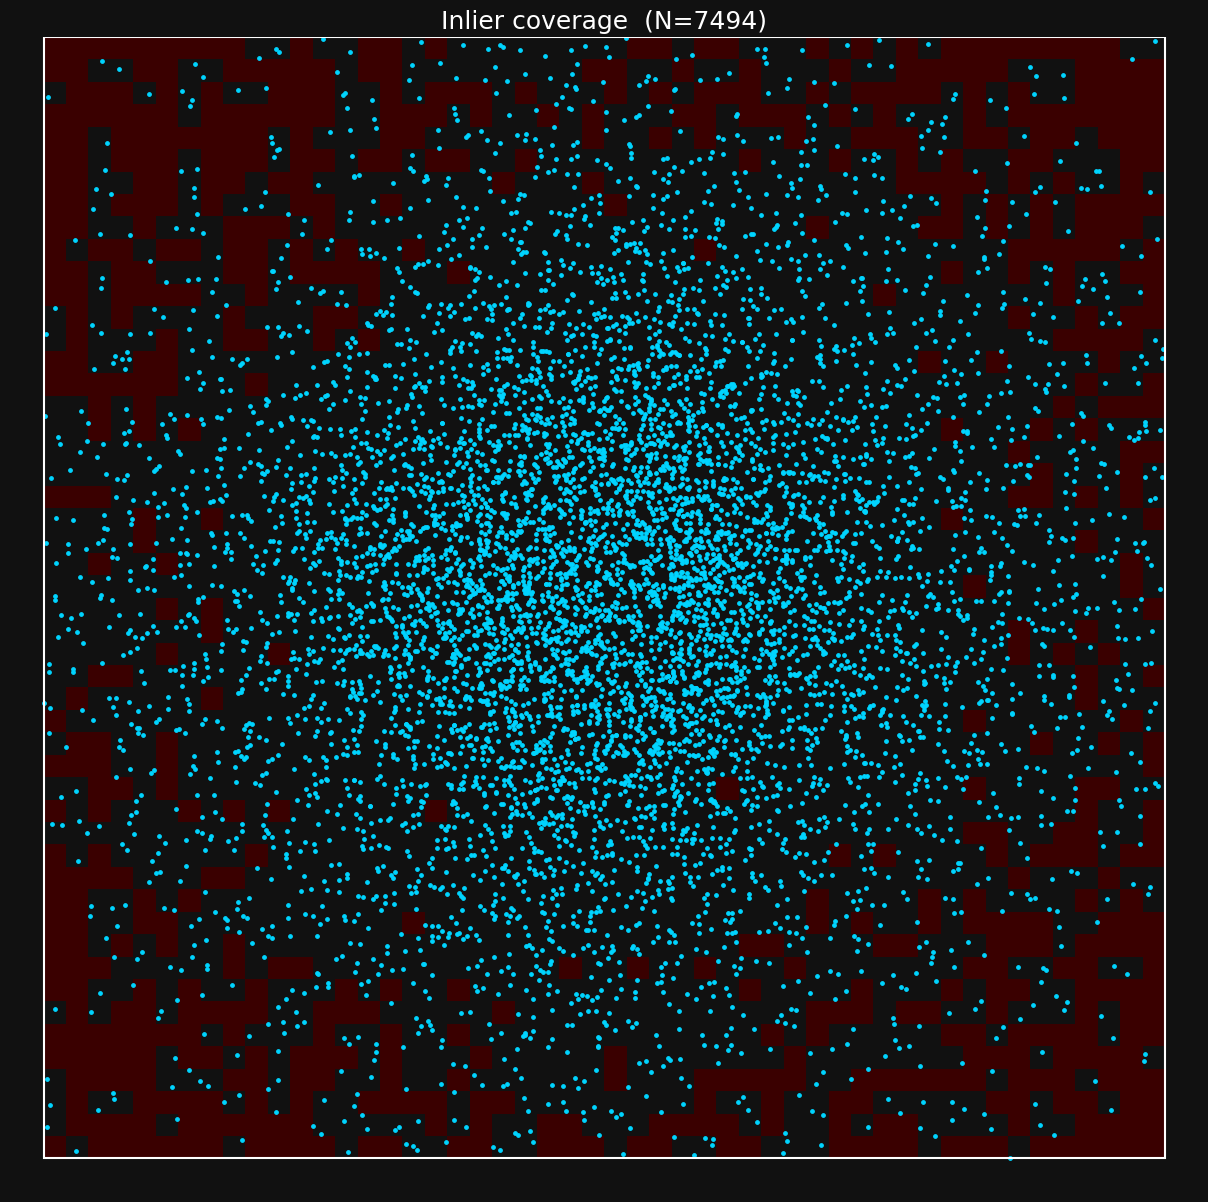

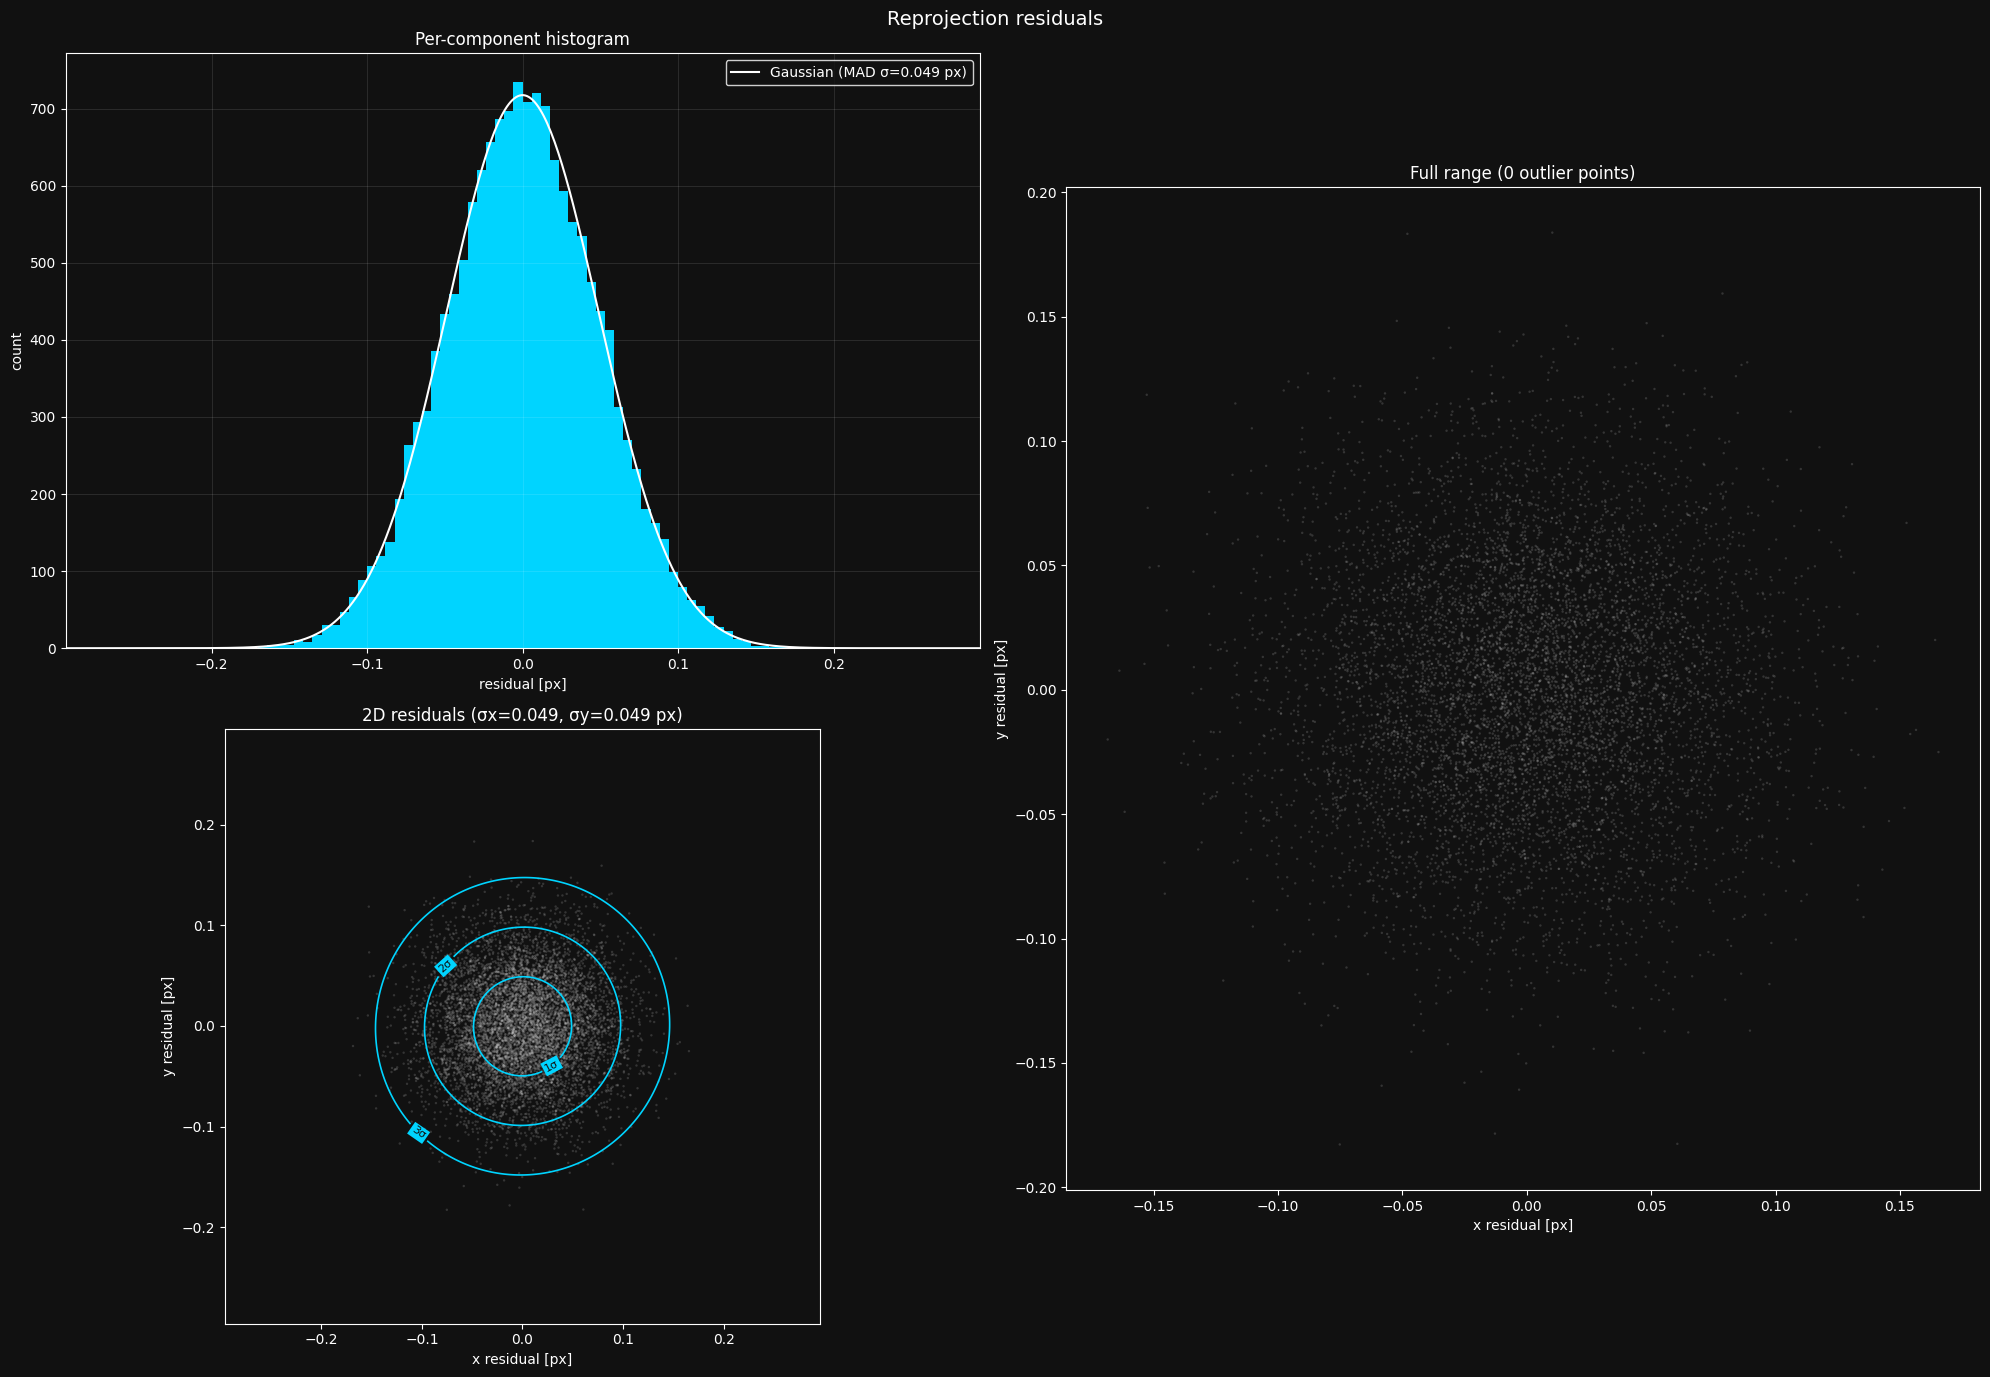

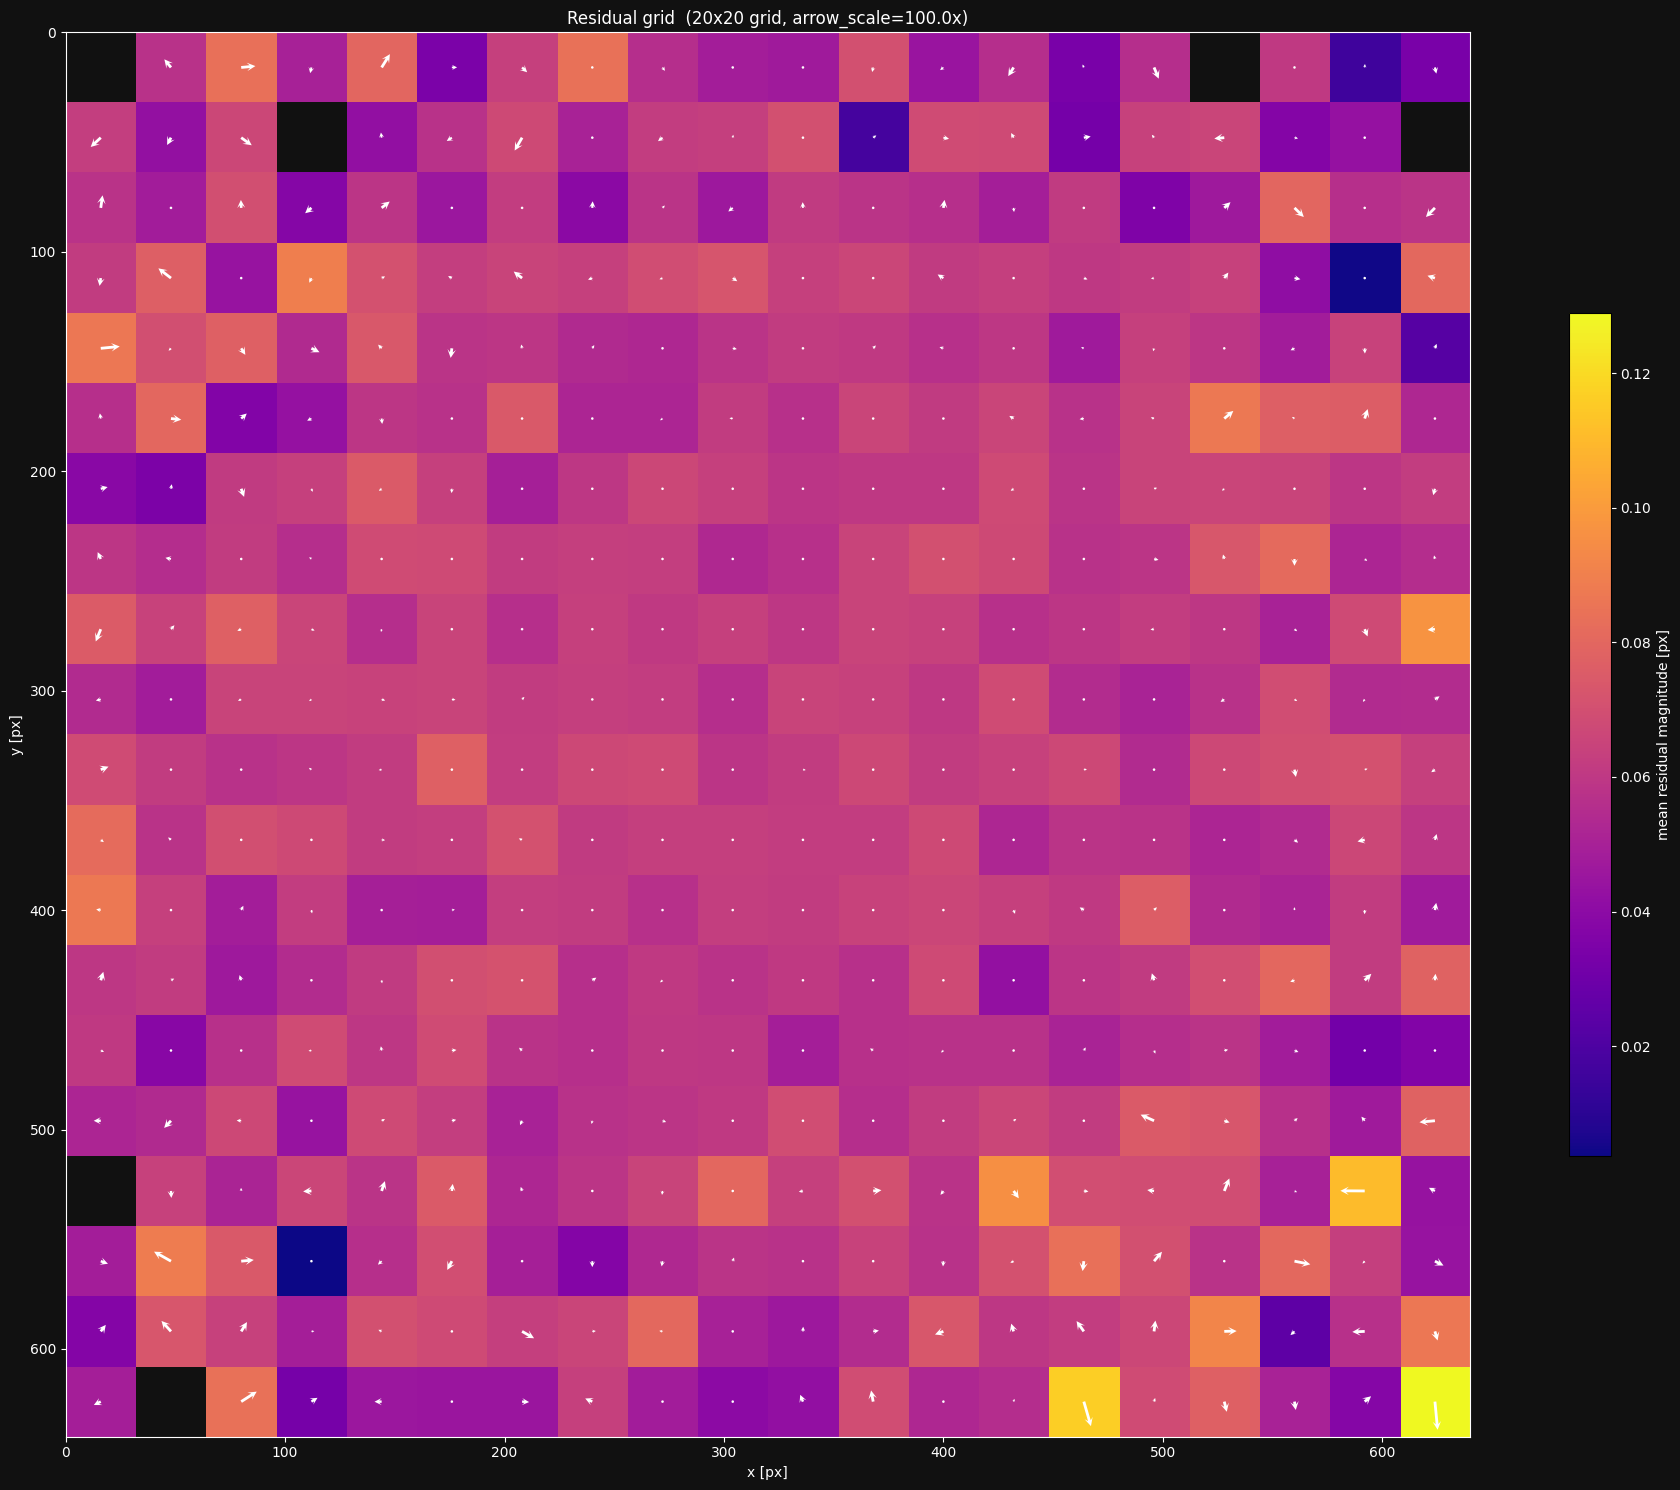

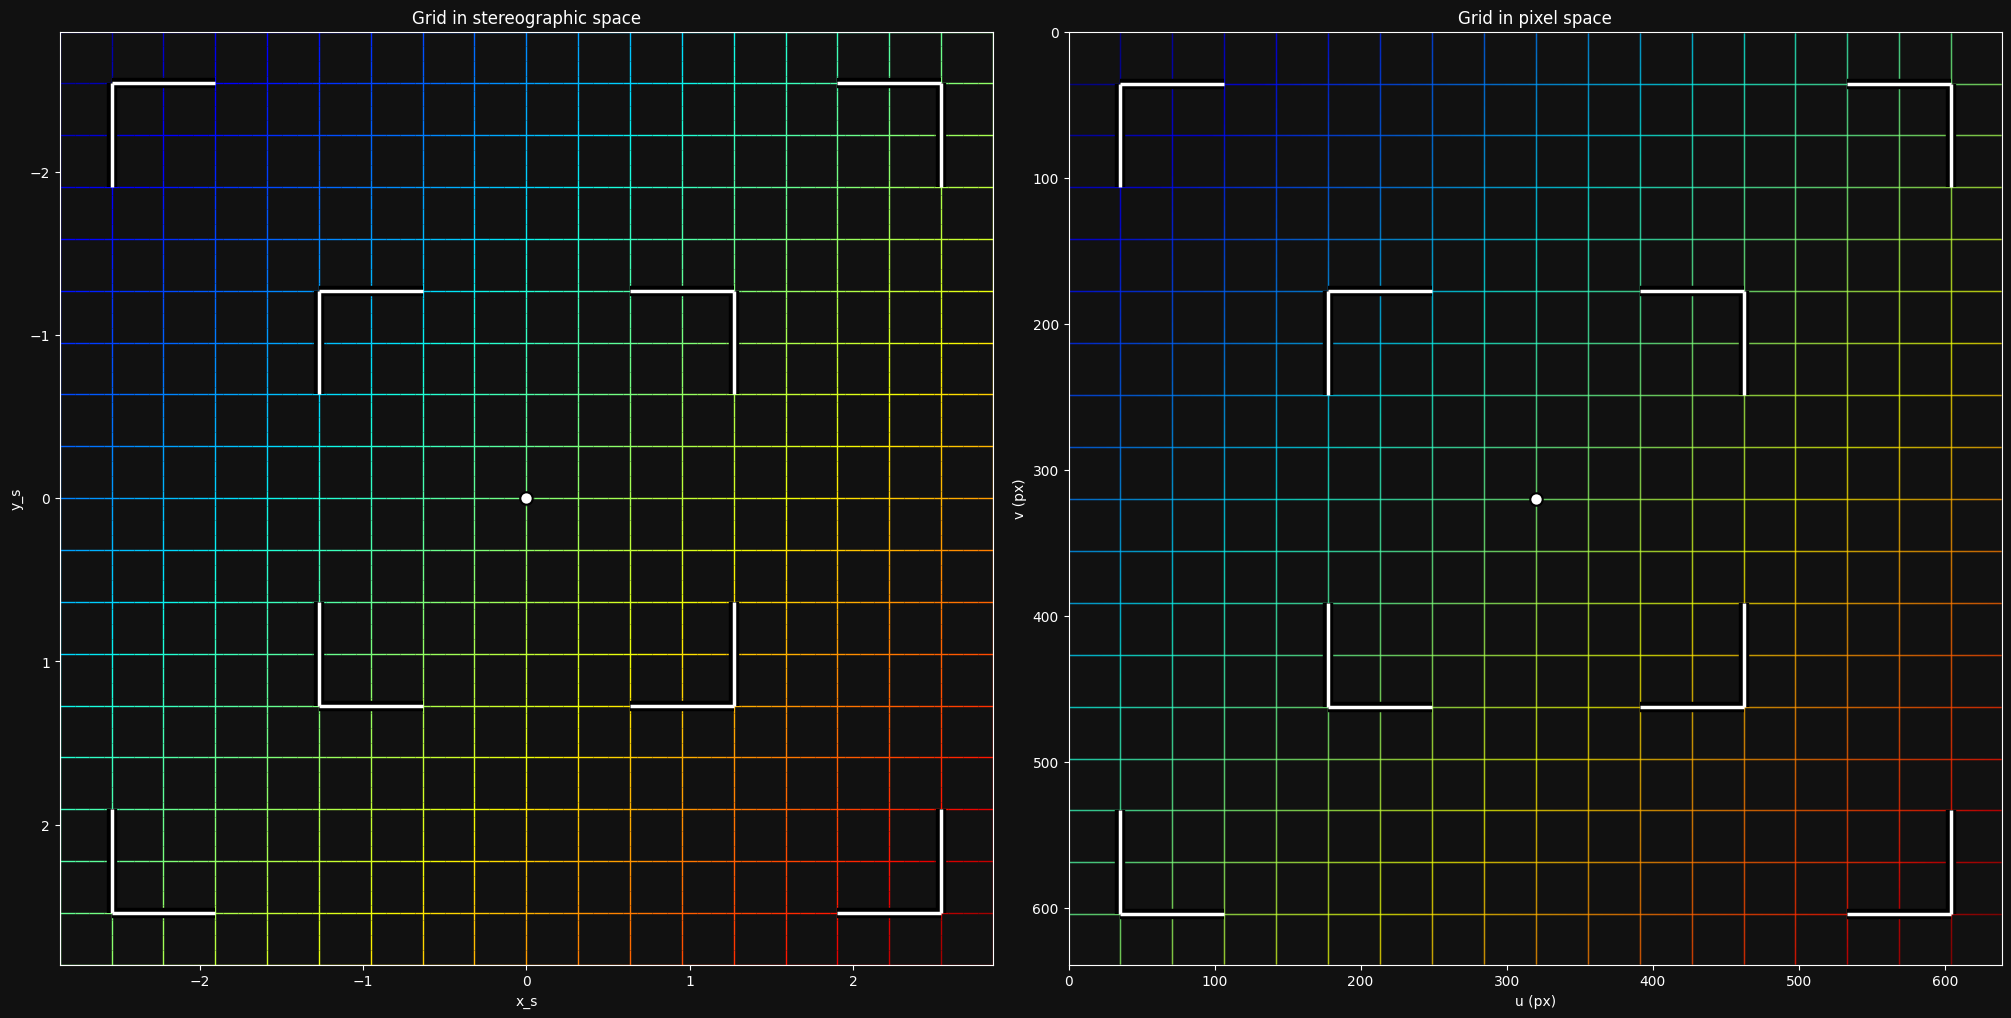

In [7]:
stereographic_opencv_result.plot_inlier_coverage()
stereographic_opencv_result.plot_residuals()
stereographic_opencv_result.plot_residual_grid(grid_cells=20)
stereographic_opencv_result.plot_distortion_grid(grid_cells=18)

## Stereographic spline diagnostics

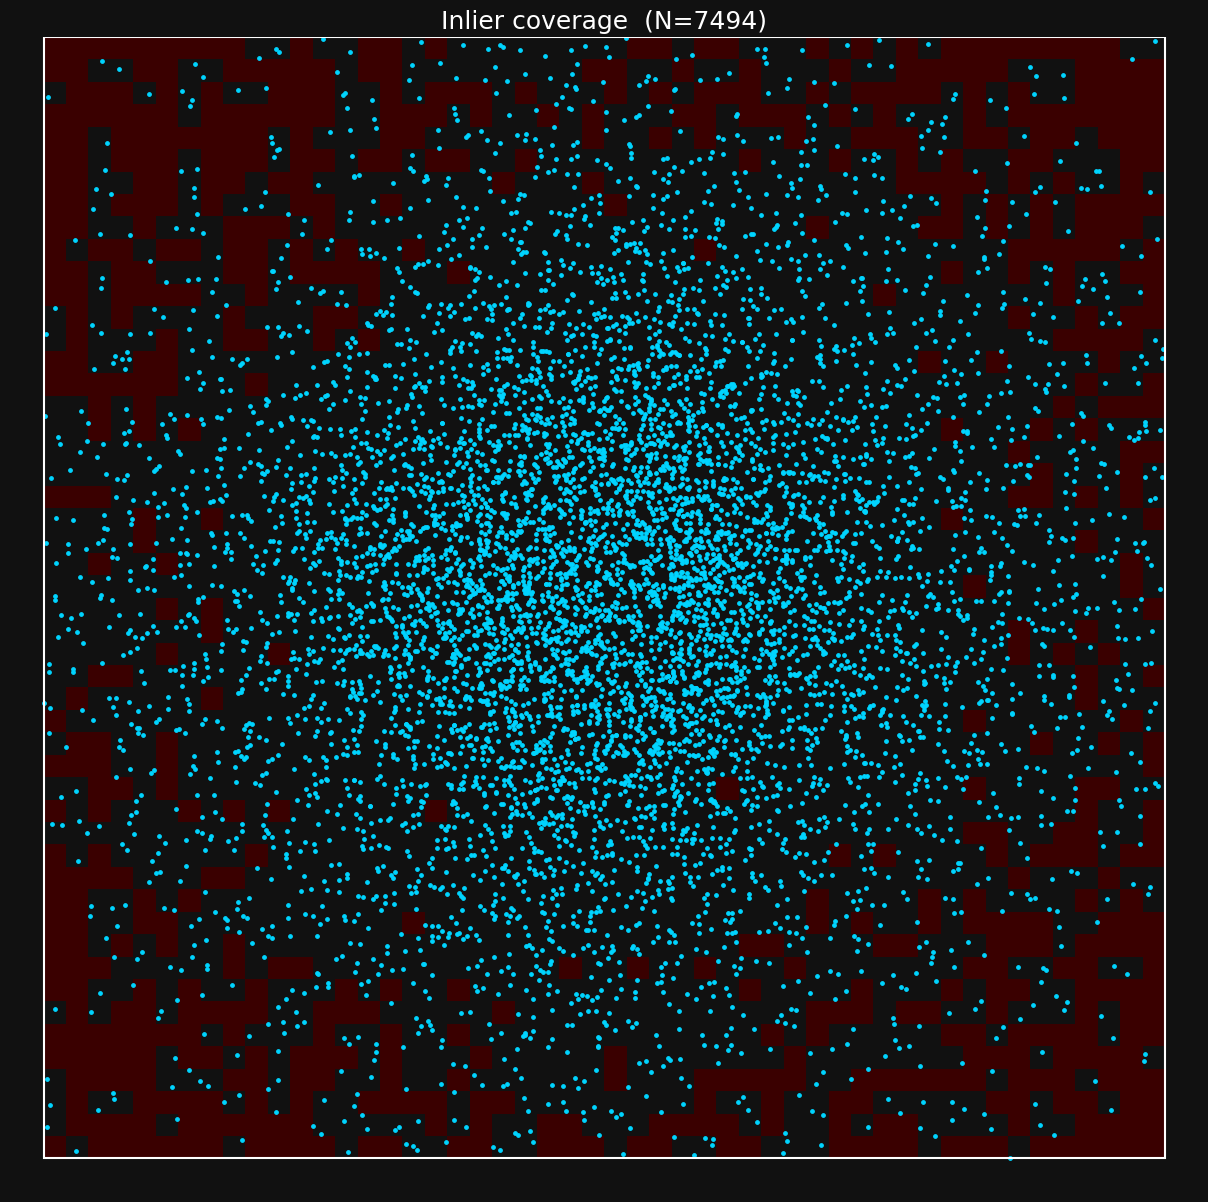

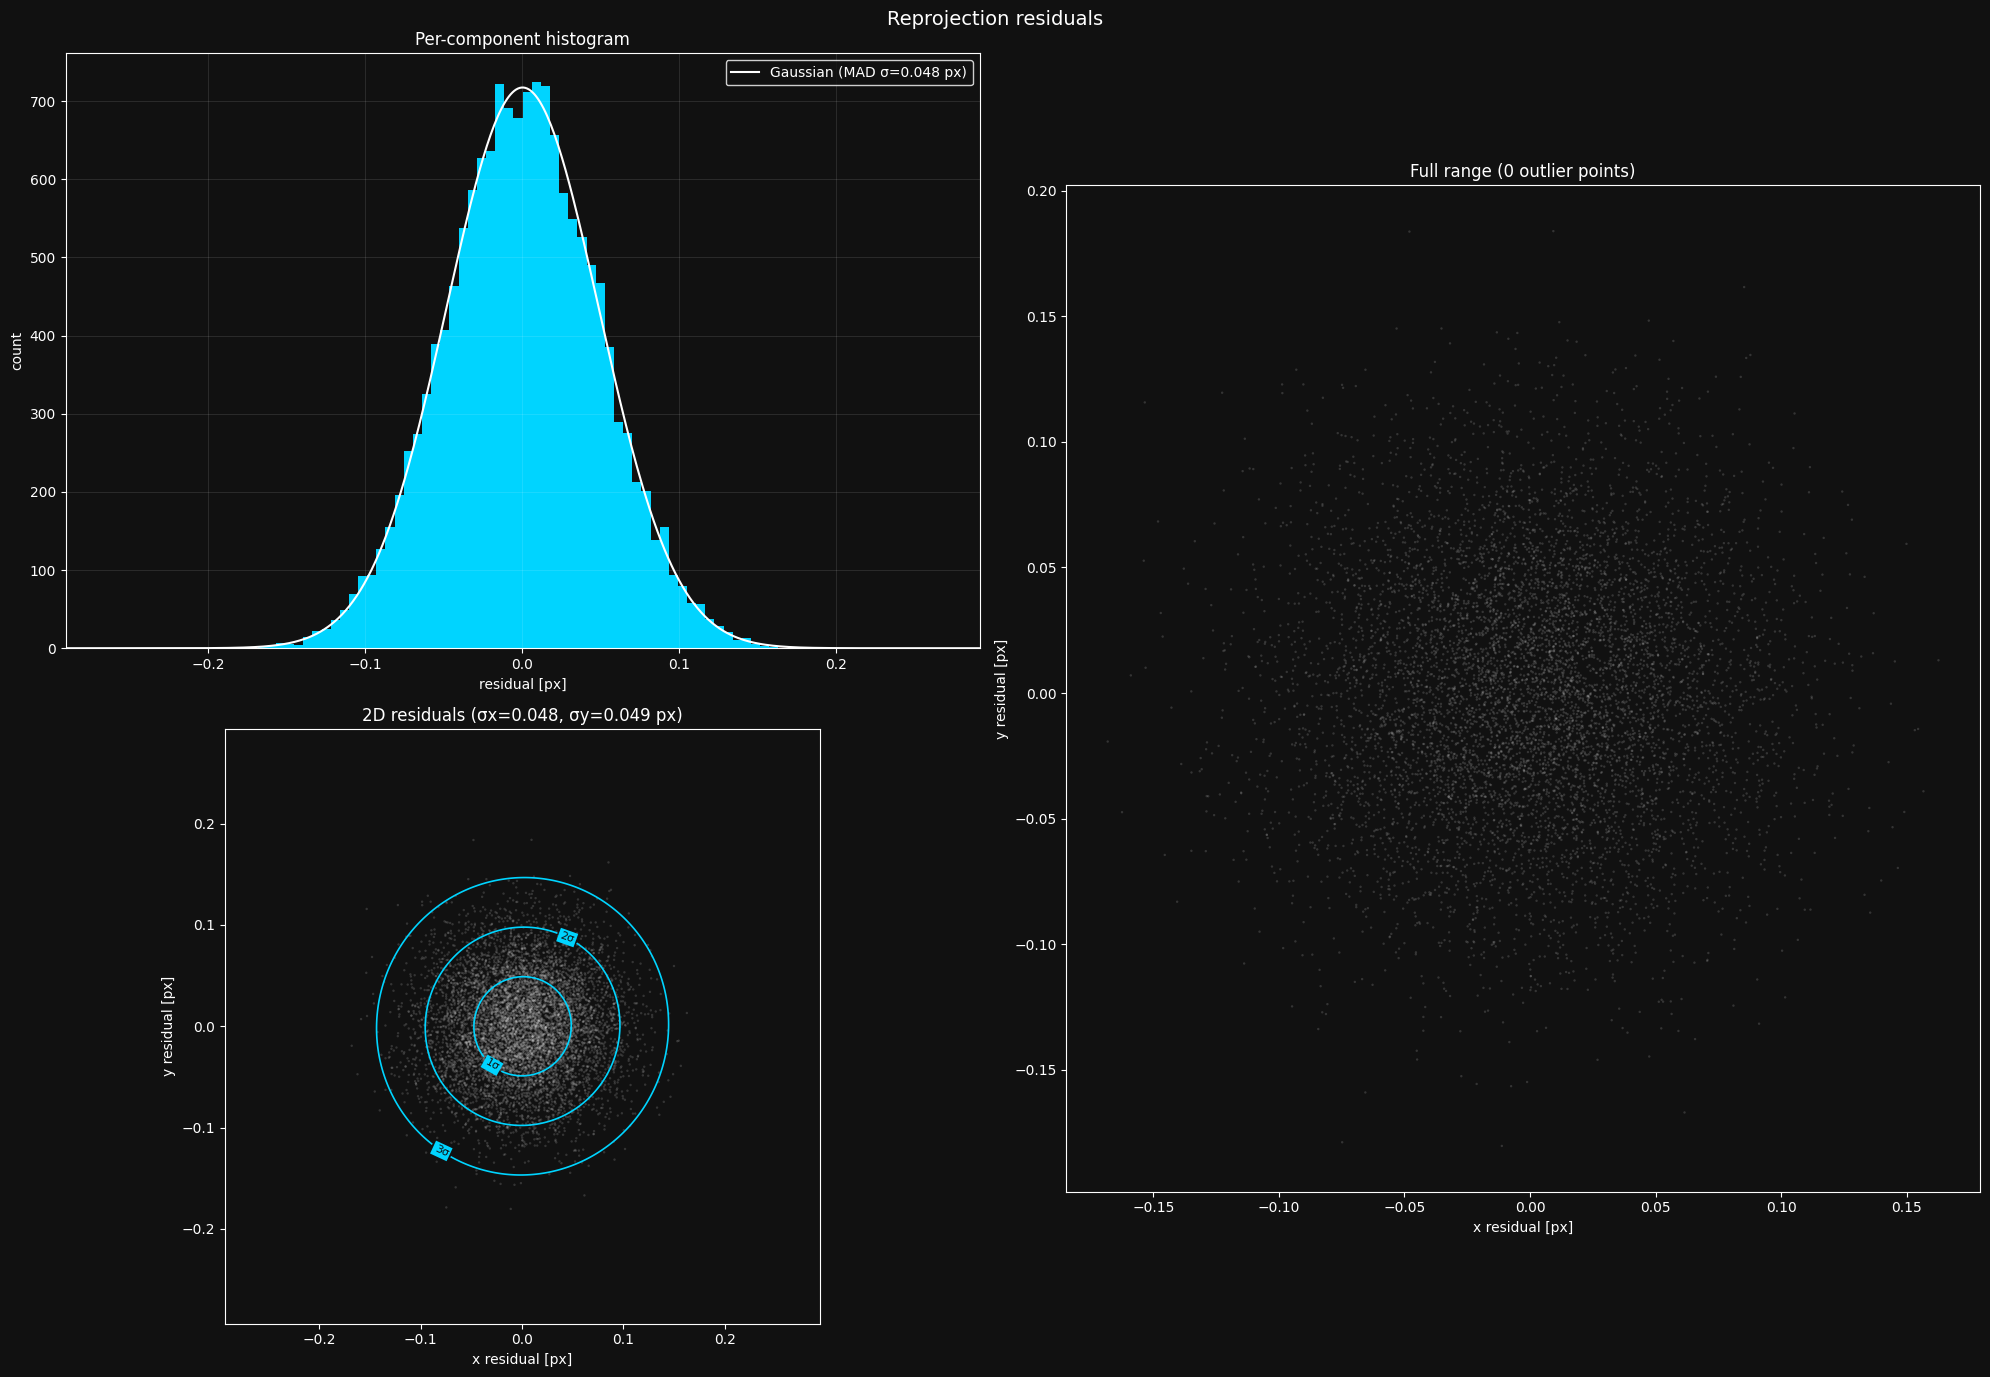

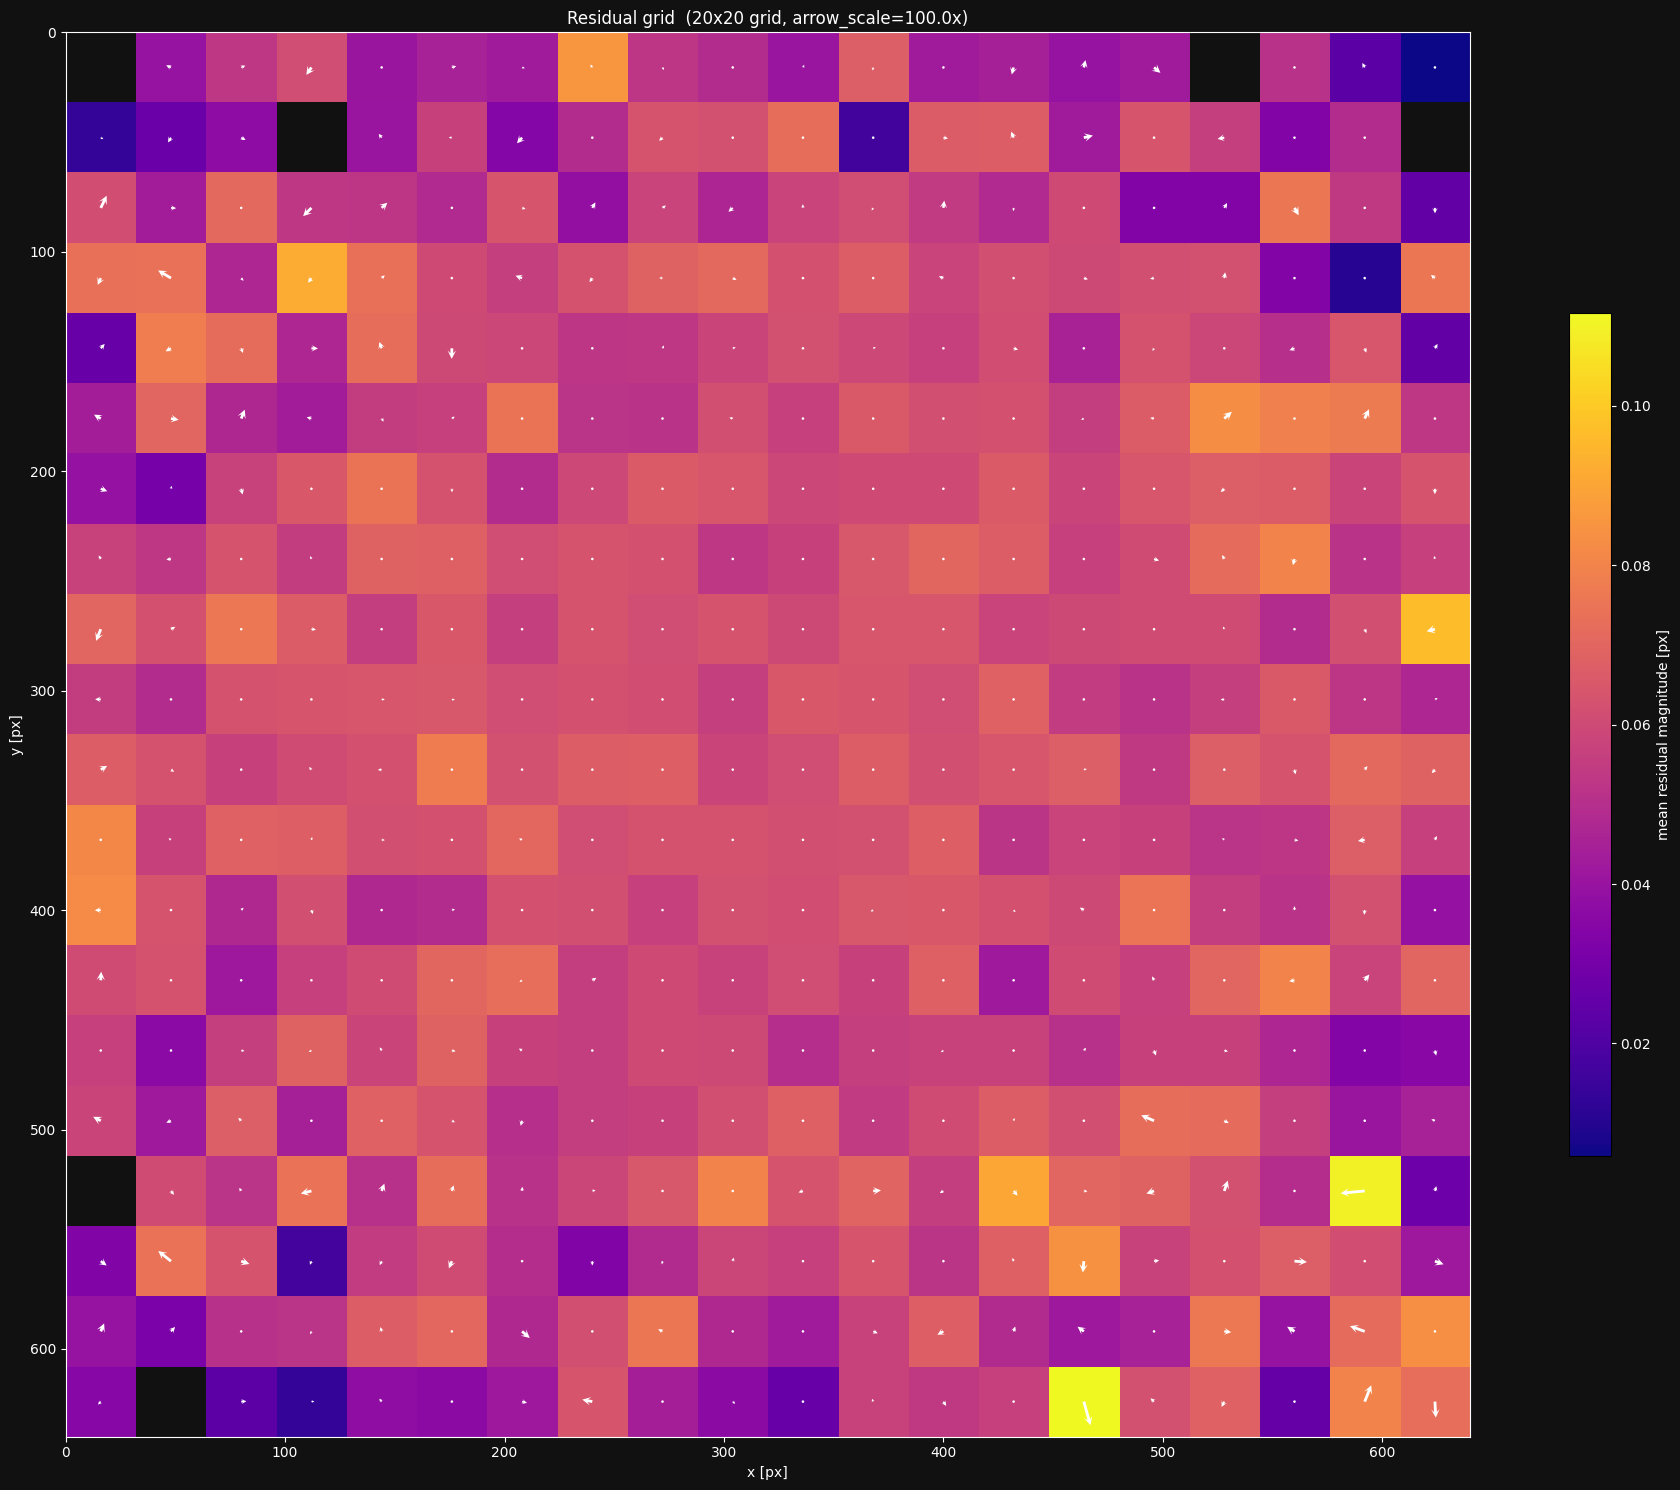

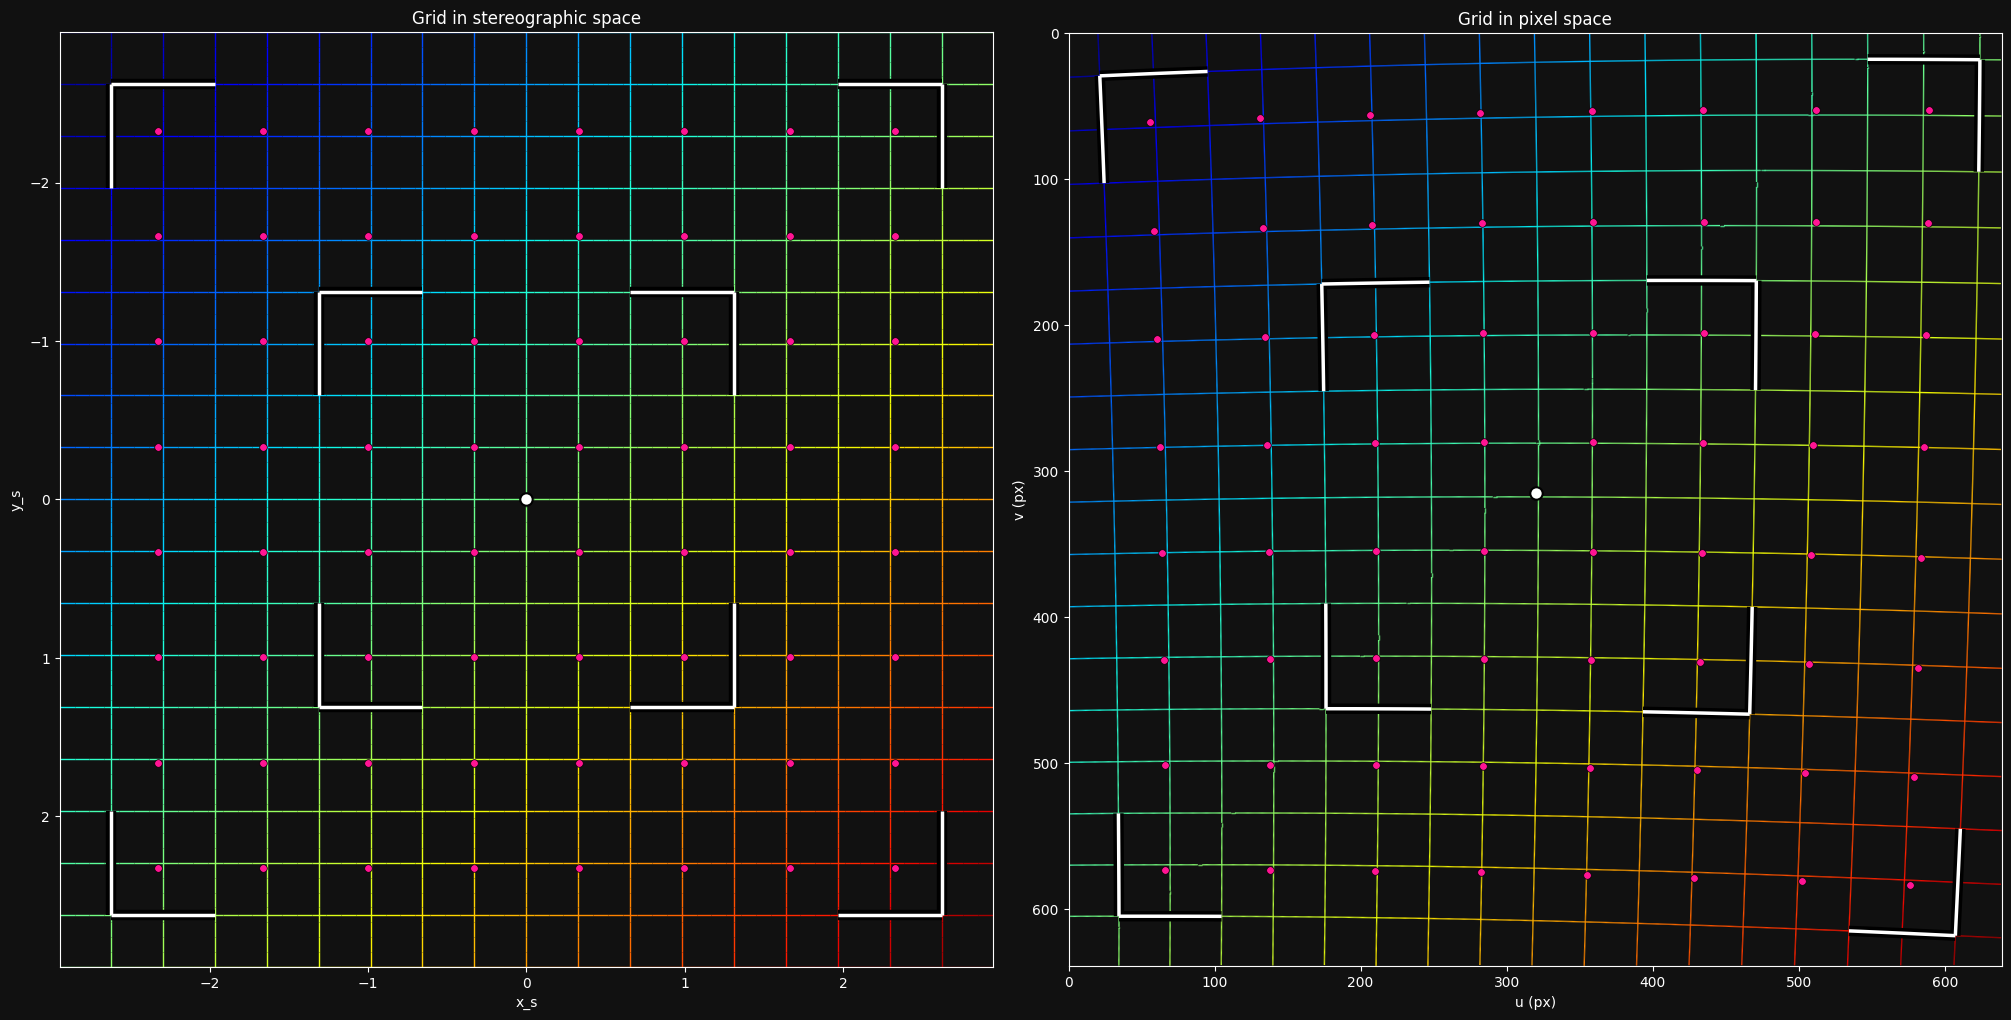

In [8]:
stereographic_spline_result.plot_inlier_coverage()
stereographic_spline_result.plot_residuals()
stereographic_spline_result.plot_residual_grid(grid_cells=20)
stereographic_spline_result.plot_distortion_grid(grid_cells=18)